# Clonal analysis for Slice culture

In [2]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sclitr as sl
import os

sc.set_figure_params(dpi=80)
sns.set_style("ticks")

In [20]:
directory='/wynton/group/pollen/jding/brainchromatin/Li/'
adata = sc.read(os.path.join(directory,'query_Slice.raw.h5ad'), compression='gzip')
adata = adata[adata.obs['batch'] == 'SlicePS']
adata.obs['Gene_target'] = adata.obs['gene_NKS']
targets = [x for x in adata.obs['Gene_target'].unique() if x in adata.var_names]
targets.append('non-targeting')
#adata = adata[adata.obs['Gene_target'].isin(targets)]
adata.obs['sex'] = [x.split('-')[-1] for x in adata.obs['individual']]
adata.obs['stage'] = [x.split('#')[0] for x in adata.obs['individual']]
adata.obs['perturbation'] = ['NT' if x in ['WT','non-targeting'] else 'Perturbed' for x in adata.obs['gene_NKS']]

/scratch/jding/ipykernel_792468/3507407600.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['Gene_target'] = adata.obs['gene_NKS']


In [3]:
adata.obs['individual'].value_counts()

individual
GW19#199-M       3909
GW19#240719-F    3416
GW22#201-F       2394
GW20#200-F        348
Name: count, dtype: int64

/wynton/home/pollenlab/jding/miniconda3/envs/cospar/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


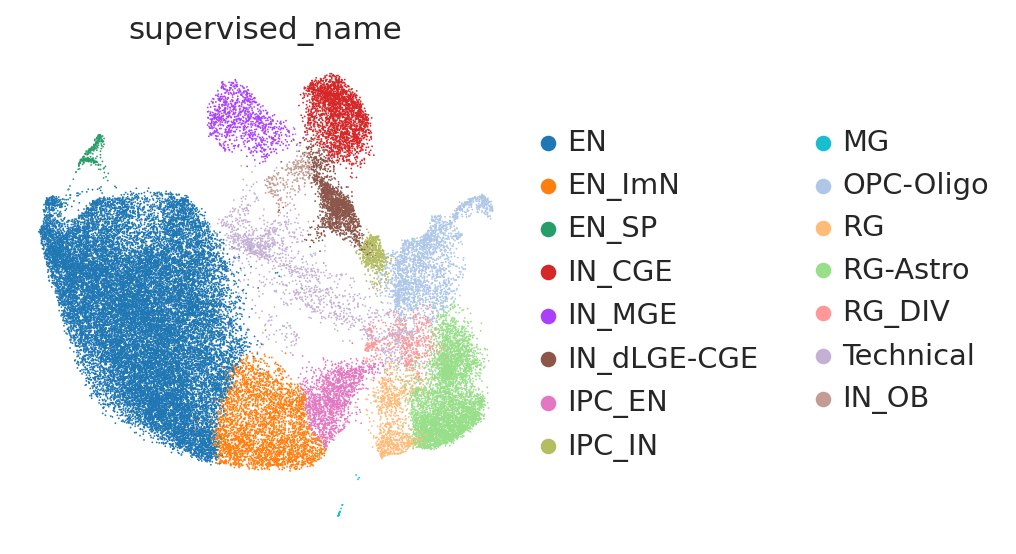

In [80]:
from matplotlib import rcParams
rcParams["figure.figsize"] = (4, 4)
sc.settings.file_format_figs='svg'
sc.pl.umap(adata, color=['supervised_name'], 
           frameon=False, legend_fontsize=13, legend_fontoutline=3,save='slice_leiden')

/wynton/home/pollenlab/jding/miniconda3/envs/cospar/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


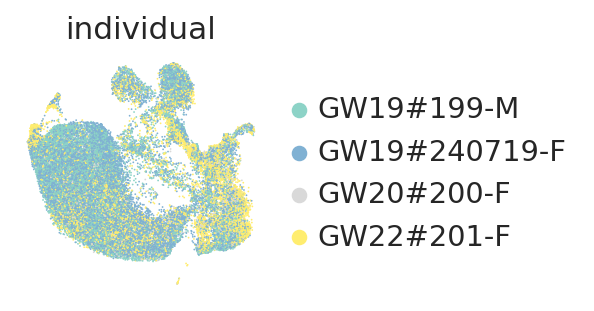

In [88]:
rcParams["figure.figsize"] = (2, 2)
sc.settings.file_format_figs='pdf'
sc.pl.umap(adata, color=['individual'],frameon=False, legend_fontsize=13, legend_fontoutline=3,
           palette='Set3',ncols=1,save='distribution-slice')

/wynton/home/pollenlab/jding/miniconda3/envs/cospar/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


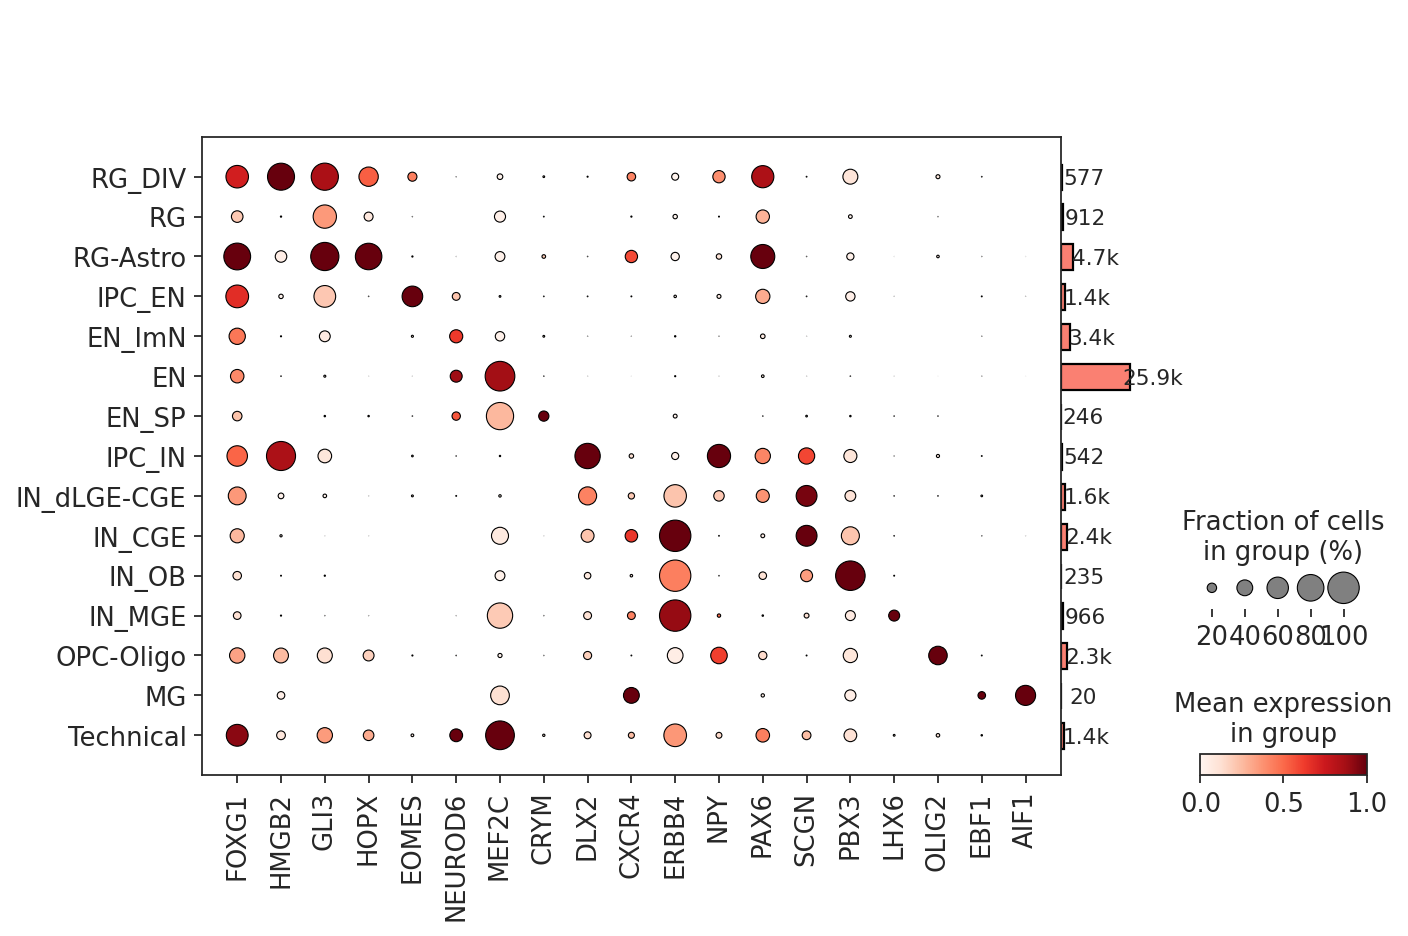

In [27]:
adata.obs['supervised_name'] = adata.obs['supervised_name'].astype('category')
#sc.tl.dendrogram(adata, 'supervised_name')
dp = sc.pl.dotplot(adata, ['FOXG1','HMGB2','GLI3','HOPX','EOMES','NEUROD6','MEF2C','CRYM','DLX2','CXCR4','ERBB4','NPY','PAX6','SCGN','PBX3','LHX6','OLIG2','EBF1','AIF1'],
                   'supervised_name', categories_order = ['RG_DIV','RG','RG-Astro','IPC_EN','EN_ImN','EN','EN_SP','IPC_IN','IN_dLGE-CGE','IN_CGE','IN_OB','IN_MGE','OPC-Oligo','MG','Technical'],
                                 standard_scale='var',dot_max=0.6, return_fig=True)
dp.add_totals().style(dot_edge_color='black', dot_edge_lw=0.5,cmap='Reds' ).savefig("./figures/dotplot.pdf")

In [31]:
adata = adata[adata.obs['gene_NKS'].isin(['non-targeting', 'NR2E1', 'SOX2', 'NEUROD2', 'ARX', 'ZNF219'])]

In [32]:
adata = adata[adata.obs["clone_barcode_criteria"] != 'no_clones_found']
adata.obs["unique_clone"] = adata.obs["clone_barcode"].astype(str) + adata.obs["individual"].astype(str)
adata.obs["time_info"] = '0'
adata.obs["time_info"].value_counts()

/scratch/jding/ipykernel_792468/3640936254.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["unique_clone"] = adata.obs["clone_barcode"].astype(str) + adata.obs["individual"].astype(str)


time_info
0    9533
Name: count, dtype: int64

<Axes: xlabel='max_percentage', ylabel='Count'>

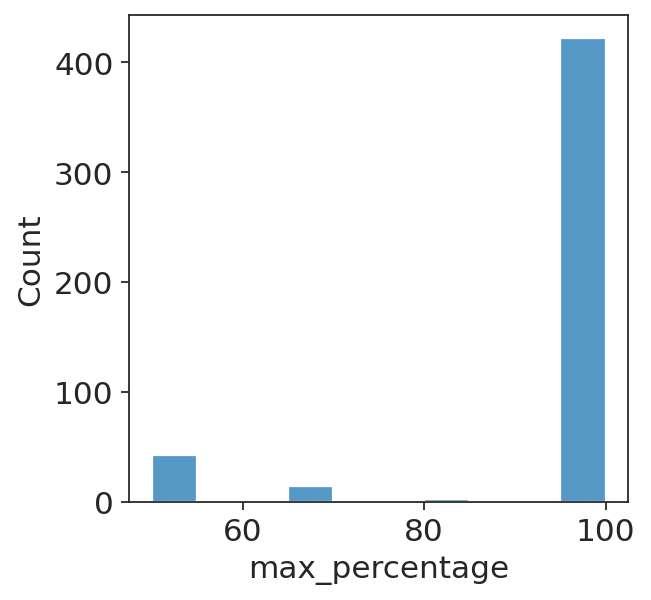

In [33]:
df = adata.obs.groupby(["unique_clone","sgRNA"]).size().reset_index(name="count")
df = df[df['count'] != 0]
df['total_count'] = df.groupby('unique_clone')['count'].transform('sum')
df['percentage'] = (df['count'] / df['total_count']) * 100
df['max_percentage'] = df.groupby('unique_clone')['percentage'].transform('max')
df = df.sort_values(by='max_percentage', ascending=False)
df = df.drop_duplicates(subset='unique_clone', keep="first")
import seaborn 
sns.histplot(data=df[df['total_count'] > 1], x="max_percentage")

In [34]:
adata = adata[adata.obs['unique_clone'].isin(df[df['max_percentage'] == 100]['unique_clone'])]

100%|███████████████████████████████████| 9474/9474 [00:00<00:00, 481968.25it/s]


reorder clones
normalize by X_clone
each selected cluster has a unique time point. Normalize per time point
Results saved as dictionary at adata.uns['fate_coupling_X_clone']


FileNotFoundError: [Errno 2] No such file or directory: 'figure/0_fate_coupling_X_clone.pdf'

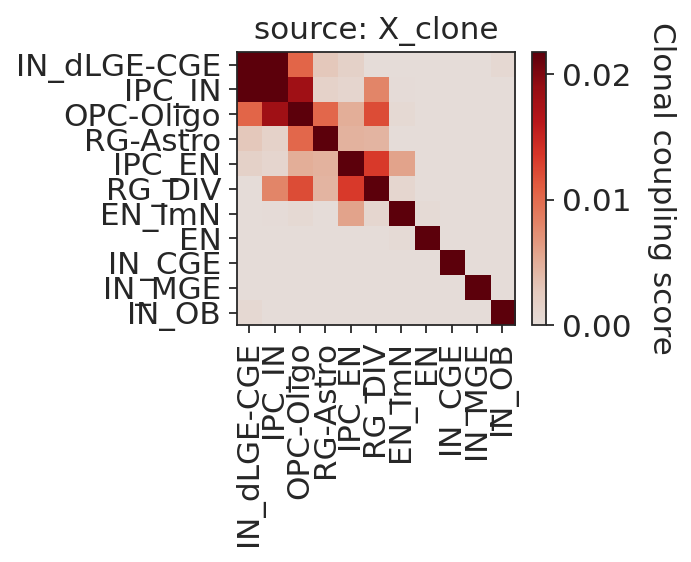

In [17]:
import cospar as cs
selected_fates = ['IPC_IN', 'RG_DIV',  'RG-Astro','OPC-Oligo', 'EN', 'IN_dLGE-CGE','IN_CGE','IN_MGE', 'IN_OB','IPC_EN','EN_ImN']
adata.uns["data_des"] = "/wynton/scratch/jding/Cellranger-7.2.0"
sub = adata
cs.pp.get_X_clone(sub,sub.obs.index.tolist(),sub.obs.unique_clone.tolist())
sub.obs["state_info"] = sub.obs['supervised_name'].astype(str)
cs.tl.fate_coupling(sub,source='X_clone',selected_fates=selected_fates) # compute the fate coupling
cs.pl.fate_coupling(sub,source='X_clone') # actually plot the coupling

/wynton/home/pollenlab/jding/miniconda3/envs/cospar/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


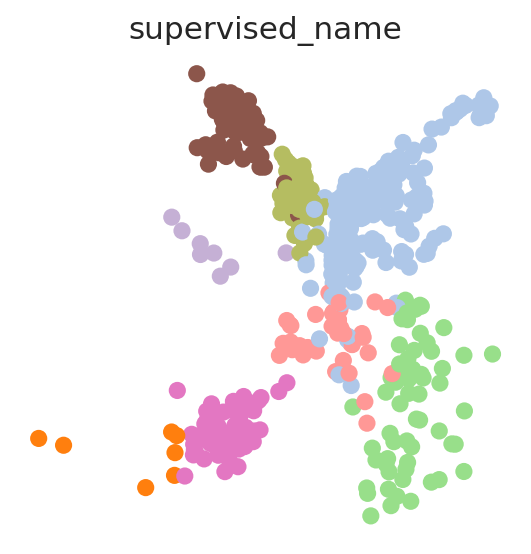

In [18]:
#clones >2 cells
df = adata.obs['unique_clone'].value_counts().reset_index(name='cellcounts')
multiclones = df[df['cellcounts'] > 2]['unique_clone'].values
adata = adata[adata.obs['unique_clone'].isin(multiclones)]
sc.pl.umap(adata, color='supervised_name', legend_loc='none',
           frameon=False, legend_fontsize=13, legend_fontoutline=3,save = 'multiclones_leiden')

Text(0.5, 0, '')

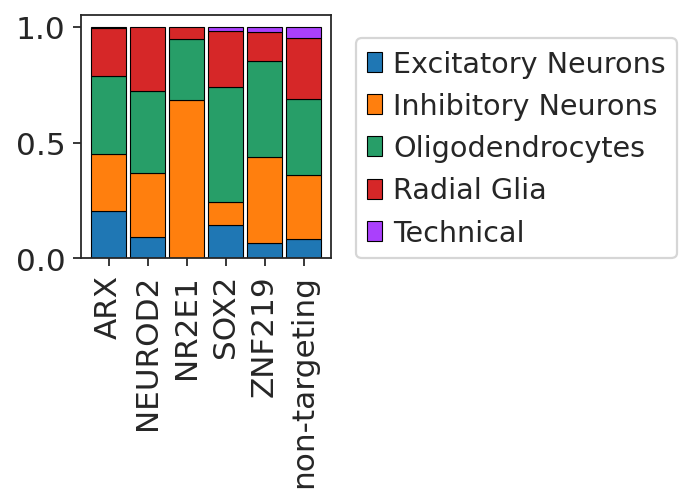

In [40]:
#visualize composition
sub = adata[adata.obs['species'].isin(['human'])]
sub = sub[sub.obs['gene_NKS'].isin(['non-targeting', 'NR2E1', 'SOX2', 'NEUROD2', 'ARX', 'ZNF219'])]
clonal_cluster_count = sub.obs.groupby([ "gene_NKS","class"]).size().reset_index().pivot(
    columns="class", index="gene_NKS", values=0
)
clonal_cluster_count = clonal_cluster_count[clonal_cluster_count.columns[clonal_cluster_count.columns != "NA"]]
clonal_cluster_count = clonal_cluster_count[clonal_cluster_count.sum(axis=1) > 5]
clonal_cluster_count = (clonal_cluster_count.T / clonal_cluster_count.sum(axis=1)).T

fig, ax = plt.subplots(figsize=(2, 2))
ax = clonal_cluster_count.plot(kind="bar", stacked=True, width=0.9, edgecolor="black",
                               #color=dict(zip(clones.obs.gene_NKS.cat.categories, clones.uns["perturbation_colors"])),
                               ax=ax, linewidth=0.5)
ax.legend(loc=(1.1, 0))
ax.set_xlabel("")

In [148]:
adata.write(os.path.join(directory,'query_SlicePS.reannotated.multiclones.h5ad'))

/wynton/home/pollenlab/jding/miniconda3/envs/cospar/lib/python3.8/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/wynton/home/pollenlab/jding/miniconda3/envs/cospar/lib/python3.8/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
